In [13]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

df = pd.read_csv("social_network_ads.csv")
print("Number of rows and columns:", df.shape)
df.head(5)


Number of rows and columns: (400, 5)


,user_id,gender,age,estimated_salary,purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [14]:
print("Missing vales:")
print(df.isna().sum())

Missing vales:
user_id             0
gender              0
age                 0
estimated_salary    0
purchased           0
dtype: int64


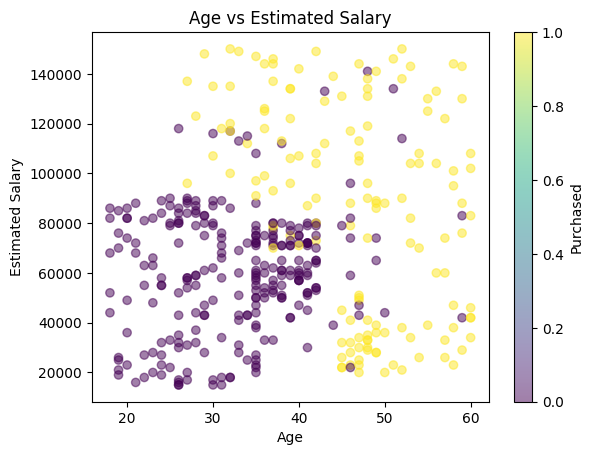

In [15]:
from matplotlib import pyplot as plt
plt.figure(figure=(10,6))
plt.scatter(df['age'], df['estimated_salary'], c=df['purchased'], cmap = 'viridis', alpha = 0.5)
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Estimated Salary")
plt.colorbar(label='Purchased')
plt.show()

In [16]:
#task2

In [17]:
df['gender'] = df['gender'].map({'Male':0,'Female':1})
X = df[['age','estimated_salary','gender']]
y= df['purchased']

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [18]:
model = LogisticRegression()

In [19]:
model.fit(X_train, y_train)

LogisticRegression()

In [22]:
print("MODEL COEF: ",model.coef_)
print("MODEL INTERCEPT: ",model.intercept_)

MODEL COEF:  [[ 1.99914592e-01  3.33049169e-05 -2.49140891e-01]]
MODEL INTERCEPT:  [-10.889199]


<bound method ClassifierMixin.score of LogisticRegression()>

In [21]:
y_pred = model.predict(X_test)
report = classification_report(y_test,y_pred)
print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.97      0.89        73
           1       0.94      0.68      0.79        47

    accuracy                           0.86       120
   macro avg       0.88      0.83      0.84       120
weighted avg       0.87      0.86      0.85       120



In [24]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.858


In [25]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[71  2]
 [15 32]]


In [31]:
#          Predicted Positive | Predicted Negative 
#-----------------------------------------------
# Actual Positive | TP         | FN
# -----------------------------------------------
# Actual Negative | FP         | TN



# TP : correctly predicted positive instances
# TN : correctly predicted negative instances
# FN : predicted negative but actually positive
# FP : predicted positive but actually negative

In [32]:
# Accuracy = (TP+TN)/total
#precision = TP/(TP+FP)
#RECALL = TP/(TP+FN)
#F1_SCORE = 2* (PRECISION * RECALL)/(PRECISON + RECALL)